# Threshold vs Top-k Retrieval Dynamics

This notebook compares threshold and top-k retrieval dynamics, diagnoses overactivation in synchronous threshold retrieval, and establishes clean baselines before fear/extinction experiments.


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from engram.hopfield import HopfieldNetwork
from engram.patterns import generate_sparse_pattern
from engram.metrics import (
    pattern_overlap, all_pattern_overlaps,
    activity_fraction, retrieval_success
)

# Global parameters (single source of truth)
N = 2000
SPARSITY = 0.1
SEED = 42
rng = np.random.default_rng(SEED)

# Shared plotting setup
FIG_DIR = "notebooks/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Global imports and parameters initialized.")


Global imports and parameters initialized.


## Why does the threshold rule overactivate? Calibrating theta.


1a - final activity fraction: 0.4295
1a - overlap with target: 0.97
1a - convergence steps: 20


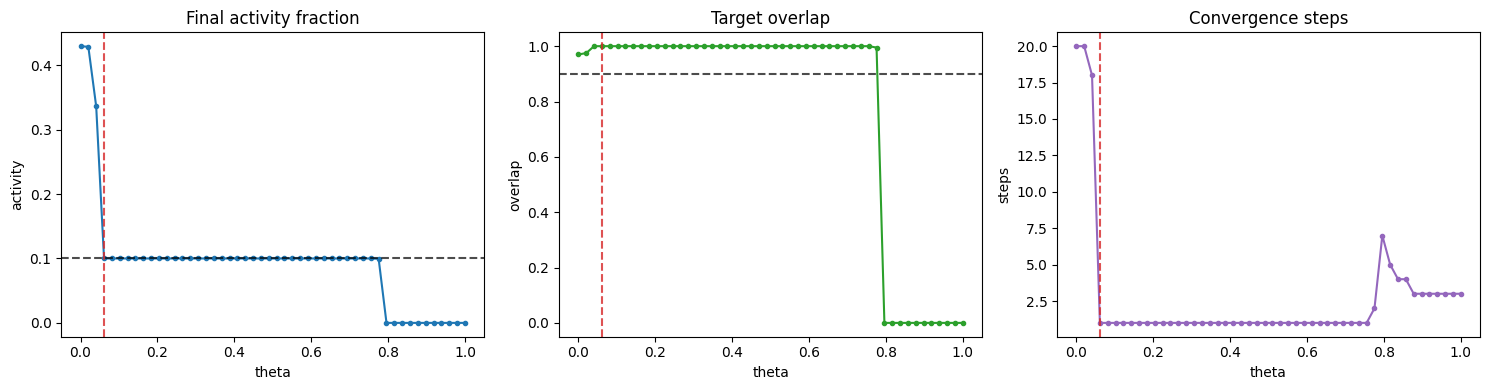

1b - theta_calibrated: 0.061224489795918366
Section 1 completed successfully.


In [ ]:
# Section 1 helpers

def make_patterns(P, rng_local):
    return np.array([generate_sparse_pattern(N, SPARSITY, rng=rng_local) for _ in range(P)])


def run_retrieval(
    net,
    cue,
    mode="threshold",
    theta=0.0,
    asynchronous=False,
    max_steps=100,
    beta=0.0,
    external_input=None,
    rng_local=None,
):
    if mode == "topk" and asynchronous:
        # Experimental async top-k: sequentially perturb then re-project to exact top-k set.
        if net._k is None:
            raise ValueError("Top-k requires sparsity_target or active_set_size.")
        if rng_local is None:
            rng_local = np.random.default_rng()
        state = cue.copy()
        trajectory = [state.copy()]
        energies = [net.energy(state, external_input=external_input, beta=beta)]
        for _ in range(max_steps):
            prev = state.copy()
            order = rng_local.permutation(net.n)
            for i in order:
                h = net.local_field(state, external_input=external_input, beta=beta)
                state[i] = int(h[i] > theta)
                h_proj = net.local_field(state, external_input=external_input, beta=beta)
                idx = np.argpartition(h_proj, -net._k)[-net._k:]
                state[:] = 0
                state[idx] = 1
            trajectory.append(state.copy())
            energies.append(net.energy(state, external_input=external_input, beta=beta))
            if np.array_equal(state, prev):
                break
        return state, trajectory, energies

    return net.run(
        initial_state=cue,
        external_input=external_input,
        beta=beta,
        theta=theta,
        max_steps=max_steps,
        asynchronous=asynchronous,
        n_sweeps=max_steps,
        rng=rng_local,
        mode=mode,
    )


def retrieve_and_diagnose_inline(
    net,
    cue_state,
    all_patterns,
    target_idx=0,
    mode="threshold",
    theta=0.0,
    asynchronous=False,
    max_steps=100,
    beta=0.0,
    external_input=None,
    rng_local=None,
):
    final_state, trajectory, _ = run_retrieval(
        net,
        cue_state,
        mode=mode,
        theta=theta,
        asynchronous=asynchronous,
        max_steps=max_steps,
        beta=beta,
        external_input=external_input,
        rng_local=rng_local,
    )
    overlaps = all_pattern_overlaps(final_state, all_patterns)
    hit_max = False
    if len(trajectory) >= 2:
        hit_max = ((len(trajectory) - 1) >= max_steps) and (not np.array_equal(trajectory[-1], trajectory[-2]))
    return {
        "final_state": final_state,
        "overlaps": overlaps,
        "target_overlap": float(overlaps[target_idx]),
        "mean_other_overlap": float(np.mean(np.delete(overlaps, target_idx))) if len(overlaps) > 1 else 0.0,
        "min_other_overlap": float(np.min(np.delete(overlaps, target_idx))) if len(overlaps) > 1 else 0.0,
        "activity": activity_fraction(final_state),
        "steps": len(trajectory) - 1,
        "hit_max_steps": int(hit_max),
        "trajectory": trajectory,
    }

# 1a: reproduce overactivation with theta=0
P = 50
patterns = make_patterns(P, rng)
net_thr = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_thr.store_patterns(patterns)

cue = patterns[0].copy()
final_state, traj, _ = run_retrieval(net_thr, cue, mode="threshold", theta=0.0, asynchronous=False, max_steps=100)
print("1a - final activity fraction:", activity_fraction(final_state))
print("1a - overlap with target:", pattern_overlap(final_state, patterns[0]))
print("1a - convergence steps:", len(traj) - 1)

# 1b: theta sweep
theta_grid = np.linspace(0.0, 1.0, 50)
act_vals, ov_vals, step_vals = [], [], []
for th in theta_grid:
    fs, tr, _ = run_retrieval(net_thr, cue, mode="threshold", theta=float(th), asynchronous=False, max_steps=20)
    act_vals.append(activity_fraction(fs))
    ov_vals.append(pattern_overlap(fs, patterns[0]))
    step_vals.append(len(tr) - 1)

act_vals = np.array(act_vals)
ov_vals = np.array(ov_vals)
step_vals = np.array(step_vals)
idx = int(np.argmin(np.abs(act_vals - SPARSITY)))
theta_calibrated = float(theta_grid[idx])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(theta_grid, act_vals, marker="o", ms=3)
axes[0].axhline(SPARSITY, ls="--", c="k", alpha=0.7)
axes[0].axvline(theta_calibrated, ls="--", c="tab:red", alpha=0.8)
axes[0].set_title("Final activity fraction")
axes[0].set_xlabel("theta")
axes[0].set_ylabel("activity")

axes[1].plot(theta_grid, ov_vals, marker="o", ms=3, c="tab:green")
axes[1].axhline(0.9, ls="--", c="k", alpha=0.7)
axes[1].axvline(theta_calibrated, ls="--", c="tab:red", alpha=0.8)
axes[1].set_title("Target overlap")
axes[1].set_xlabel("theta")
axes[1].set_ylabel("overlap")

axes[2].plot(theta_grid, step_vals, marker="o", ms=3, c="tab:purple")
axes[2].axvline(theta_calibrated, ls="--", c="tab:red", alpha=0.8)
axes[2].set_title("Convergence steps")
axes[2].set_xlabel("theta")
axes[2].set_ylabel("steps")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section1_theta_calibration.png", dpi=160)
plt.show()

print("1b - theta_calibrated:", theta_calibrated)
print("Section 1 completed successfully.")


The threshold must be calibrated so that converged activity fraction approximately matches stored sparsity (`SPARSITY = 0.1`). Without this, synchronous threshold retrieval can overactivate many neurons and distort overlap behavior. Under top-k, this calibration is automatic and exact because each step enforces exactly `k = SPARSITY * N` active neurons.


## Single memory, both rules: sanity check


In [9]:
# Section 2
patterns_p1 = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng)])
cue_p1 = patterns_p1[0].copy()

# Threshold (calibrated)
net_thr_p1 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_thr_p1.store_patterns(patterns_p1)
fs_thr, tr_thr, _ = run_retrieval(net_thr_p1, cue_p1, mode="threshold", theta=theta_calibrated, asynchronous=False, max_steps=100)

# Top-k
net_topk_p1 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
net_topk_p1.store_patterns(patterns_p1)
fs_topk, tr_topk, _ = run_retrieval(net_topk_p1, cue_p1, mode="topk", asynchronous=False, max_steps=100)

print("Threshold (calibrated)")
print("  final activity fraction:", activity_fraction(fs_thr))
print("  overlap:", pattern_overlap(fs_thr, patterns_p1[0]))
print("  convergence steps:", len(tr_thr) - 1)
print("  exact match:", bool(np.array_equal(fs_thr, patterns_p1[0])))

print("Top-k")
print("  final activity fraction:", activity_fraction(fs_topk))
print("  overlap:", pattern_overlap(fs_topk, patterns_p1[0]))
print("  convergence steps:", len(tr_topk) - 1)
print("  exact match:", bool(np.array_equal(fs_topk, patterns_p1[0])))

print("Section 2 completed successfully.")


Threshold (calibrated)
  final activity fraction: 0.1
  overlap: 1.0
  convergence steps: 1
  exact match: True
Top-k
  final activity fraction: 0.1
  overlap: 1.0
  convergence steps: 1
  exact match: True
Section 2 completed successfully.


## Update mode comparison: does the network actually converge?


In [10]:
# Section 3 helpers

def corrupt_with_fraction(pattern, corruption_fraction, rng_local):
    out = pattern.copy()
    n_flip = int(round(len(pattern) * corruption_fraction))
    if n_flip > 0:
        idx = rng_local.choice(len(pattern), size=n_flip, replace=False)
        out[idx] = 1 - out[idx]
    return out


def eval_condition(net, patterns_local, mode, asynchronous, theta, trials=10, corruption=0.3, max_steps=100):
    rows = []
    for _ in range(trials):
        cue_trial = corrupt_with_fraction(patterns_local[0], corruption, rng)
        result = retrieve_and_diagnose_inline(
            net,
            cue_trial,
            patterns_local,
            target_idx=0,
            mode=mode,
            theta=theta,
            asynchronous=asynchronous,
            max_steps=max_steps,
            rng_local=rng,
        )
        rows.append(result)

    mean_overlap = float(np.mean([r["target_overlap"] for r in rows]))
    mean_activity = float(np.mean([r["activity"] for r in rows]))
    mean_steps = float(np.mean([r["steps"] for r in rows]))
    nonconv_rate = float(np.mean([r["hit_max_steps"] for r in rows]))
    return mean_overlap, mean_activity, mean_steps, nonconv_rate

P3 = 50
patterns3 = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P3)])

net_thr3 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_thr3.store_patterns(patterns3)

net_topk3 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
net_topk3.store_patterns(patterns3)

conditions = [
    ("A. Threshold + synchronous", net_thr3, "threshold", False, theta_calibrated),
    ("B. Threshold + asynchronous", net_thr3, "threshold", True, theta_calibrated),
    ("C. Top-k + synchronous", net_topk3, "topk", False, 0.0),
    ("D. Top-k + asynchronous (experimental)", net_topk3, "topk", True, 0.0),
]

print("Condition | Mean overlap | Mean activity | Mean steps | Non-convergence rate")
print("-" * 85)
for name, net, mode, async_flag, theta_val in conditions:
    mo, ma, ms, nr = eval_condition(net, patterns3, mode, async_flag, theta_val, trials=10)
    print(f"{name:38s} | {mo:11.3f} | {ma:13.3f} | {ms:10.2f} | {nr:20.2f}")

print("Section 3 completed successfully.")


Condition | Mean overlap | Mean activity | Mean steps | Non-convergence rate
-------------------------------------------------------------------------------------
A. Threshold + synchronous             |       0.979 |         0.348 |      33.80 |                 0.20
B. Threshold + asynchronous            |       0.995 |         0.348 |       9.70 |                 0.00
C. Top-k + synchronous                 |       1.000 |         0.100 |       2.80 |                 0.00
D. Top-k + asynchronous (experimental) |       1.000 |         0.100 |       2.00 |                 0.00
Section 3 completed successfully.


Non-convergence under synchronous threshold at high load is expected and typically reflects limit cycles rather than true attractor settling. Asynchronous threshold updates are guaranteed to converge under the classic energy argument. Top-k convergence is empirical; asynchronous top-k behavior here is experimental.


## Memory interference profile: threshold (calibrated) vs top-k


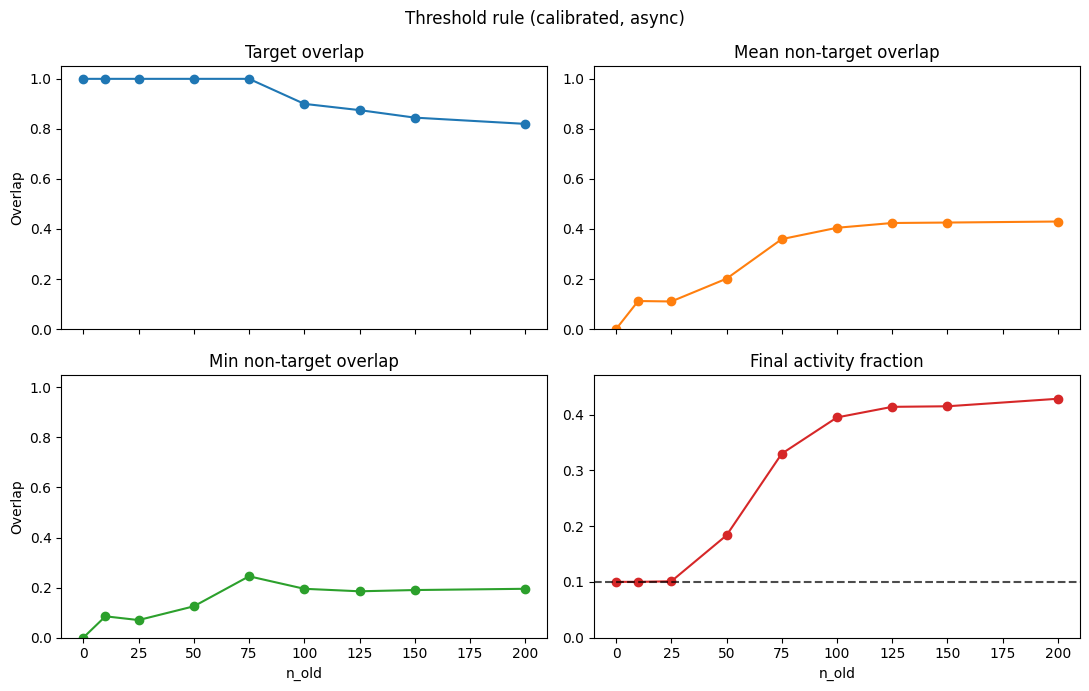

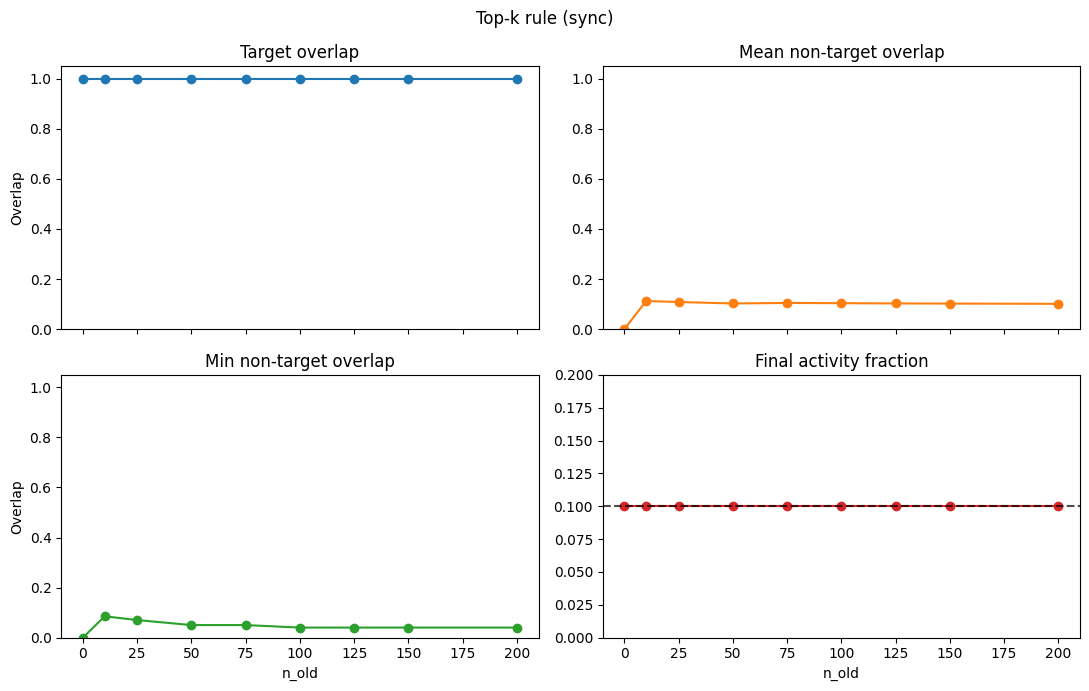

Note: Threshold activity drifts above 0.1 at higher load for some n_old values.
Section 4 completed successfully.


In [11]:
# Section 4
n_old_values = [0, 10, 25, 50, 75, 100, 125, 150, 200]
P_total = max(n_old_values) + 1
patterns4 = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P_total)])

net_thr4 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_topk4 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)

results = {
    "threshold": {"target": [], "mean_other": [], "min_other": [], "activity": [], "steps": []},
    "topk": {"target": [], "mean_other": [], "min_other": [], "activity": [], "steps": []},
}

for n_old in n_old_values:
    subset = patterns4[: n_old + 1]
    cue = subset[0].copy()

    net_thr4.reset_weights()
    net_thr4.store_patterns(list(subset))
    diag_thr = retrieve_and_diagnose_inline(
        net_thr4,
        cue,
        subset,
        target_idx=0,
        mode="threshold",
        theta=theta_calibrated,
        asynchronous=True,
        max_steps=100,
        rng_local=rng,
    )

    net_topk4.reset_weights()
    net_topk4.store_patterns(list(subset))
    diag_topk = retrieve_and_diagnose_inline(
        net_topk4,
        cue,
        subset,
        target_idx=0,
        mode="topk",
        asynchronous=False,
        max_steps=100,
        rng_local=rng,
    )

    for key, diag in [("threshold", diag_thr), ("topk", diag_topk)]:
        results[key]["target"].append(diag["target_overlap"])
        results[key]["mean_other"].append(diag["mean_other_overlap"])
        results[key]["min_other"].append(diag["min_other_overlap"])
        results[key]["activity"].append(diag["activity"])
        results[key]["steps"].append(diag["steps"])


def interference_figure(rule_key, title, out_name):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
    x = n_old_values
    r = results[rule_key]

    axes[0, 0].plot(x, r["target"], marker="o")
    axes[0, 0].set_title("Target overlap")
    axes[0, 0].set_ylabel("Overlap")
    axes[0, 0].set_ylim(0, 1.05)

    axes[0, 1].plot(x, r["mean_other"], marker="o", c="tab:orange")
    axes[0, 1].set_title("Mean non-target overlap")
    axes[0, 1].set_ylim(0, 1.05)

    axes[1, 0].plot(x, r["min_other"], marker="o", c="tab:green")
    axes[1, 0].set_title("Min non-target overlap")
    axes[1, 0].set_xlabel("n_old")
    axes[1, 0].set_ylabel("Overlap")
    axes[1, 0].set_ylim(0, 1.05)

    axes[1, 1].plot(x, r["activity"], marker="o", c="tab:red")
    axes[1, 1].axhline(SPARSITY, ls="--", c="k", alpha=0.7)
    axes[1, 1].set_title("Final activity fraction")
    axes[1, 1].set_xlabel("n_old")
    axes[1, 1].set_ylim(0, max(0.2, max(r["activity"]) * 1.1))

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{out_name}", dpi=160)
    plt.show()

interference_figure("threshold", "Threshold rule (calibrated, async)", "03_section4_threshold_interference.png")
interference_figure("topk", "Top-k rule (sync)", "03_section4_topk_interference.png")

thr_activity_arr = np.array(results["threshold"]["activity"])
if np.any(thr_activity_arr > SPARSITY + 0.02):
    print("Note: Threshold activity drifts above 0.1 at higher load for some n_old values.")
else:
    print("Threshold activity remains near 0.1 across n_old sweep.")

print("Section 4 completed successfully.")


## Retrieval fingerprint: what else gets activated when you cue each memory?


C:\Users\armaa\AppData\Local\Temp\ipykernel_86436\1001846188.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


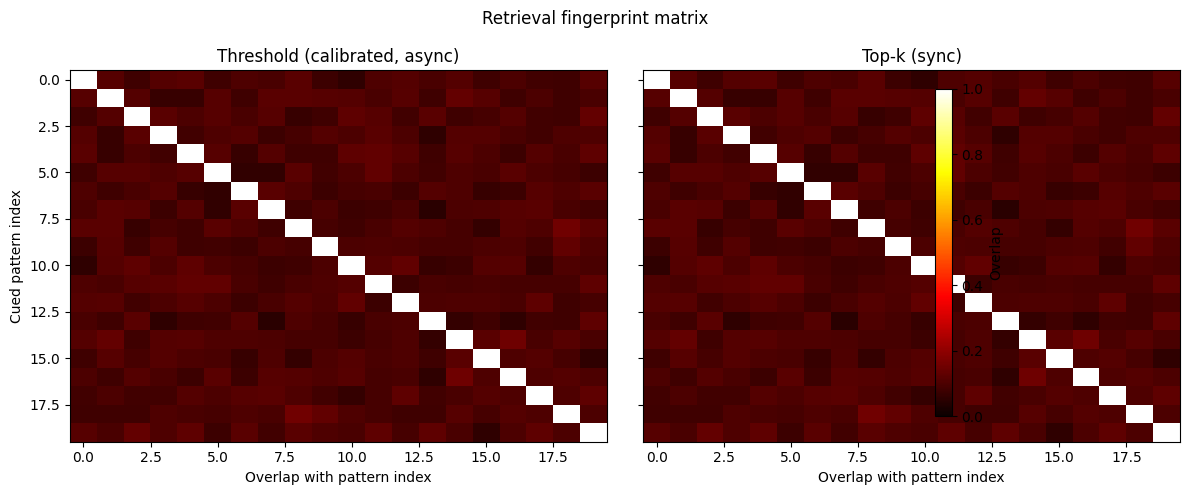

Section 5 completed successfully.


In [12]:
# Section 5
P5 = 20
patterns5 = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P5)])

net_thr5 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_thr5.store_patterns(patterns5)

net_topk5 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
net_topk5.store_patterns(patterns5)

M_thr = np.zeros((P5, P5))
M_topk = np.zeros((P5, P5))

for mu in range(P5):
    cue = patterns5[mu].copy()

    fs_thr, _, _ = run_retrieval(
        net_thr5,
        cue,
        mode="threshold",
        theta=theta_calibrated,
        asynchronous=True,
        max_steps=100,
        rng_local=rng,
    )
    M_thr[mu] = all_pattern_overlaps(fs_thr, patterns5)

    fs_topk, _, _ = run_retrieval(
        net_topk5,
        cue,
        mode="topk",
        asynchronous=False,
        max_steps=100,
        rng_local=rng,
    )
    M_topk[mu] = all_pattern_overlaps(fs_topk, patterns5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
im0 = axes[0].imshow(M_thr, cmap="hot", vmin=0, vmax=1, aspect="auto")
axes[0].set_title("Threshold (calibrated, async)")
axes[0].set_xlabel("Overlap with pattern index")
axes[0].set_ylabel("Cued pattern index")

im1 = axes[1].imshow(M_topk, cmap="hot", vmin=0, vmax=1, aspect="auto")
axes[1].set_title("Top-k (sync)")
axes[1].set_xlabel("Overlap with pattern index")

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("Overlap")
fig.suptitle("Retrieval fingerprint matrix")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section5_fingerprint_heatmaps.png", dpi=160)
plt.show()

print("Section 5 completed successfully.")


## Does top-k actually enforce sparsity during dynamics?


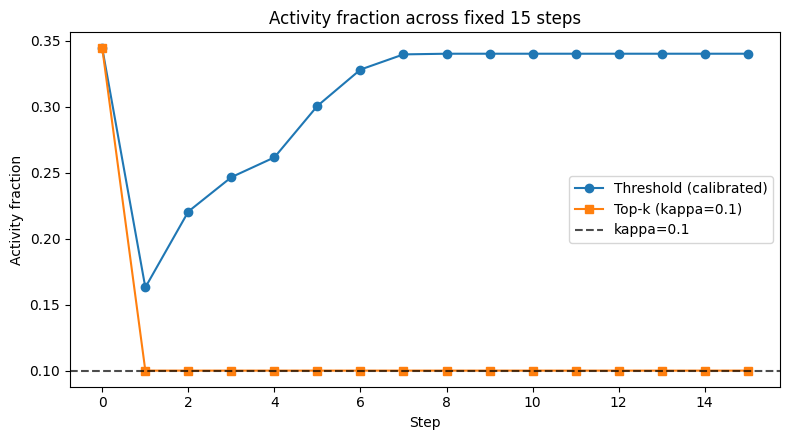

Section 6 completed successfully.


In [19]:
# Section 6
P6 = 50
patterns6 = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P6)])
cue6 = patterns6[0].copy()

# Corrupt by 0.3
n_flip6 = int(round(N * 0.3))
flip_idx6 = rng.choice(N, size=n_flip6, replace=False)
cue6[flip_idx6] = 1 - cue6[flip_idx6]

net_thr6 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_thr6.store_patterns(patterns6)

net_topk6 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
net_topk6.store_patterns(patterns6)

steps = np.arange(16)

# Force exactly 15 synchronous steps (no early stop)
state_thr = cue6.copy()
state_topk = cue6.copy()
act_thr = [activity_fraction(state_thr)]
act_topk = [activity_fraction(state_topk)]

for _ in range(15):
    state_thr = net_thr6.update_synchronous(state_thr, theta=theta_calibrated)
    state_topk = net_topk6.update_topk(state_topk, beta=0.0)
    act_thr.append(activity_fraction(state_thr))
    act_topk.append(activity_fraction(state_topk))

plt.figure(figsize=(8, 4.5))
plt.plot(steps, act_thr, marker="o", label="Threshold (calibrated)")
plt.plot(steps, act_topk, marker="s", label="Top-k (kappa=0.1)")
plt.axhline(SPARSITY, ls="--", c="k", alpha=0.7, label="kappa=0.1")
plt.xlabel("Step")
plt.ylabel("Activity fraction")
plt.title("Activity fraction across fixed 15 steps")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section6_activity_conservation.png", dpi=160)
plt.show()

print("Section 6 completed successfully.")


## Effect of cue strength beta under top-k: does it bias the competition without causing overactivation?


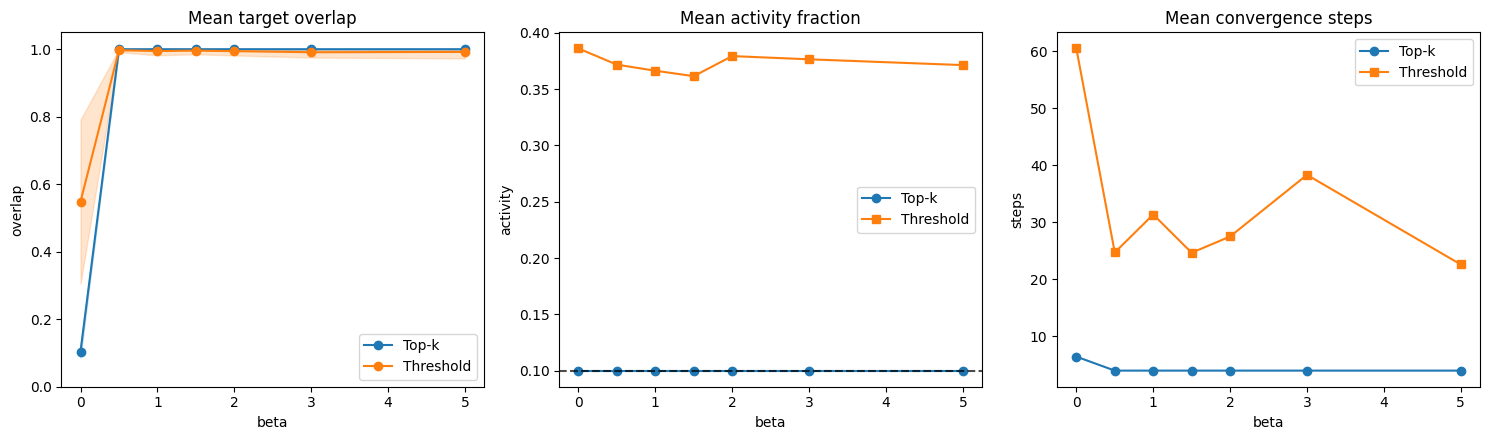

Section 7 completed successfully.


In [14]:
# Section 7 helpers

def generate_cs_input_local(pattern, cue_fraction, rng_local):
    idx = np.where(pattern == 1)[0]
    n = int(round(len(idx) * cue_fraction))
    cue = np.zeros_like(pattern)
    if n > 0:
        on_idx = rng_local.choice(idx, size=n, replace=False)
        cue[on_idx] = 1
    return cue


def corrupt_local(pattern, frac, rng_local):
    out = pattern.copy()
    n_flip = int(round(len(pattern) * frac))
    if n_flip > 0:
        idx = rng_local.choice(len(pattern), size=n_flip, replace=False)
        out[idx] = 1 - out[idx]
    return out

P7 = 50
patterns7 = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P7)])
external_cue = generate_cs_input_local(patterns7[0], cue_fraction=0.5, rng_local=rng)
betas = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0])

net_thr7 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_thr7.store_patterns(patterns7)

net_topk7 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
net_topk7.store_patterns(patterns7)

stats = {
    "topk": {"ov_mean": [], "ov_std": [], "act_mean": [], "steps_mean": []},
    "threshold": {"ov_mean": [], "ov_std": [], "act_mean": [], "steps_mean": []},
}

for beta in betas:
    rows_topk, rows_thr = [], []
    for _ in range(20):
        cue_trial = corrupt_local(patterns7[0], 0.5, rng)

        d_topk = retrieve_and_diagnose_inline(
            net_topk7,
            cue_trial,
            patterns7,
            target_idx=0,
            mode="topk",
            asynchronous=False,
            max_steps=100,
            beta=float(beta),
            external_input=external_cue,
            rng_local=rng,
        )
        rows_topk.append(d_topk)

        d_thr = retrieve_and_diagnose_inline(
            net_thr7,
            cue_trial,
            patterns7,
            target_idx=0,
            mode="threshold",
            theta=theta_calibrated,
            asynchronous=False,
            max_steps=100,
            beta=float(beta),
            external_input=external_cue,
            rng_local=rng,
        )
        rows_thr.append(d_thr)

    for key, rows in [("topk", rows_topk), ("threshold", rows_thr)]:
        ovs = np.array([r["target_overlap"] for r in rows])
        acts = np.array([r["activity"] for r in rows])
        stp = np.array([r["steps"] for r in rows])
        stats[key]["ov_mean"].append(float(np.mean(ovs)))
        stats[key]["ov_std"].append(float(np.std(ovs)))
        stats[key]["act_mean"].append(float(np.mean(acts)))
        stats[key]["steps_mean"].append(float(np.mean(stp)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for key, label, color in [
    ("topk", "Top-k", "tab:blue"),
    ("threshold", "Threshold", "tab:orange"),
]:
    m = np.array(stats[key]["ov_mean"])
    s = np.array(stats[key]["ov_std"])
    axes[0].plot(betas, m, marker="o", label=label, color=color)
    axes[0].fill_between(betas, np.clip(m - s, 0, 1), np.clip(m + s, 0, 1), color=color, alpha=0.2)

axes[0].set_title("Mean target overlap")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("overlap")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].plot(betas, stats["topk"]["act_mean"], marker="o", label="Top-k")
axes[1].plot(betas, stats["threshold"]["act_mean"], marker="s", label="Threshold")
axes[1].axhline(SPARSITY, ls="--", c="k", alpha=0.7)
axes[1].set_title("Mean activity fraction")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("activity")
axes[1].legend()

axes[2].plot(betas, stats["topk"]["steps_mean"], marker="o", label="Top-k")
axes[2].plot(betas, stats["threshold"]["steps_mean"], marker="s", label="Threshold")
axes[2].set_title("Mean convergence steps")
axes[2].set_xlabel("beta")
axes[2].set_ylabel("steps")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section7_beta_sweep.png", dpi=160)
plt.show()

print("Section 7 completed successfully.")


## Summary: threshold vs top-k at P=100


In [15]:
# Section 8
P8 = 100
patterns8 = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P8)])

net_thr8 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY)
net_thr8.store_patterns(patterns8)

net_topk8 = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=SPARSITY)
net_topk8.store_patterns(patterns8)

summary_conditions = [
    ("Threshold (calibrated)", "async", net_thr8, "threshold", True, theta_calibrated),
    ("Threshold (calibrated)", "sync", net_thr8, "threshold", False, theta_calibrated),
    ("Top-k (kappa=0.1)", "sync", net_topk8, "topk", False, 0.0),
    ("Top-k (kappa=0.1)", "async", net_topk8, "topk", True, 0.0),
]

rows_out = []
for rule, update, net, mode, async_flag, theta_val in summary_conditions:
    trials = []
    for _ in range(20):
        cue_trial = patterns8[0].copy()
        n_flip = int(round(N * 0.3))
        idx = rng.choice(N, size=n_flip, replace=False)
        cue_trial[idx] = 1 - cue_trial[idx]
        diag = retrieve_and_diagnose_inline(
            net,
            cue_trial,
            patterns8,
            target_idx=0,
            mode=mode,
            theta=theta_val,
            asynchronous=async_flag,
            max_steps=100,
            rng_local=rng,
        )
        trials.append(diag)

    rows_out.append({
        "Rule": rule,
        "Update": update,
        "Activity": float(np.mean([t["activity"] for t in trials])),
        "Target Overlap": float(np.mean([t["target_overlap"] for t in trials])),
        "Non-convergence Rate": float(np.mean([t["hit_max_steps"] for t in trials])),
        "Mean Other Overlap": float(np.mean([t["mean_other_overlap"] for t in trials])),
    })

header = ["Rule", "Update", "Activity", "Target Overlap", "Non-convergence Rate", "Mean Other Overlap"]
print(" | ".join(header))
print("-" * 110)
for r in rows_out:
    print(
        f"{r['Rule']:24s} | {r['Update']:6s} | {r['Activity']:8.3f} | "
        f"{r['Target Overlap']:14.3f} | {r['Non-convergence Rate']:20.3f} | {r['Mean Other Overlap']:18.3f}"
    )

print("Section 8 completed successfully.")


Rule | Update | Activity | Target Overlap | Non-convergence Rate | Mean Other Overlap
--------------------------------------------------------------------------------------------------------------
Threshold (calibrated)   | async  |    0.419 |          0.793 |                0.000 |              0.427
Threshold (calibrated)   | sync   |    0.415 |          0.808 |                0.500 |              0.425
Top-k (kappa=0.1)        | sync   |    0.100 |          1.000 |                0.000 |              0.100
Top-k (kappa=0.1)        | async  |    0.100 |          1.000 |                0.000 |              0.100
Section 8 completed successfully.


Across these diagnostics, calibrated threshold and top-k can both support retrieval, but they differ strongly in activity control and convergence behavior. Top-k enforces exact sparsity by construction, while threshold requires careful calibration and may drift under changing load/cue conditions. Synchronous threshold non-convergence at high load should be interpreted as dynamical cycling rather than attractor settling; asynchronous threshold is the cleaner baseline. Open questions for the next notebook: how these dynamics interact with fear/extinction manipulations, and whether beta-driven cue competition qualitatively changes interference structure under each update rule.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Top-k-only constants for Sections 9-11
KAPPA = 0.1
K = 200
MAX_STEPS_9_11 = 20


def substitute_corrupt(pattern, f_corrupt, rng):
    """
    Substitution corruption: flip f_corrupt fraction of active
    neurons OFF, replace with equal number of inactive neurons ON.
    Total activity stays exactly at sparsity (K=200 neurons).
    """
    state = pattern.copy().astype(float)
    active_idx = np.where(pattern == 1)[0]
    inactive_idx = np.where(pattern == 0)[0]
    n_flip = int(f_corrupt * len(active_idx))
    if n_flip == 0:
        return state
    off_idx = rng.choice(active_idx, n_flip, replace=False)
    state[off_idx] = 0
    on_idx = rng.choice(inactive_idx, n_flip, replace=False)
    state[on_idx] = 1
    return state


def generate_mixed_cue(target, f_engram, cue_sparsity, rng, N):
    """
    Mixed cue: total activity = cue_sparsity * N neurons.
    Of these, f_engram fraction come from target active set,
    remainder come from background (non-target) neurons.
    """
    n_cue_total = int(cue_sparsity * N)
    active_idx = np.where(target == 1)[0]
    inactive_idx = np.where(target == 0)[0]
    n_signal = min(int(f_engram * n_cue_total), len(active_idx))
    n_background = n_cue_total - n_signal
    cue = np.zeros(N)
    if n_signal > 0:
        cue[rng.choice(active_idx, n_signal, replace=False)] = 1
    if n_background > 0:
        cue[rng.choice(inactive_idx, n_background, replace=False)] = 1
    return cue


print("Section 9-11 helpers initialized.")

Section 9-11 helpers initialized.


c:\Users\armaa\anaconda3\envs\engram\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Substitution corruption resilience: basic top-k associative memory test

This is the fundamental test of top-k as an associative memory.
The initial state is a corrupted version of the stored pattern
with EXACTLY the same total activity (K=200 neurons). A fraction
f_corrupt of the active neurons are wrong (substituted).
No external drive, no background noise beyond the substitutions.

This isolates the core question: given that exactly K neurons
are active and some fraction are incorrect, do the recurrent
field dynamics h=Ws rank correct neurons above incorrect ones
in the top-k competition?

If yes: top-k is functioning as a true associative memory.
If no: the weight matrix signal is insufficient to overcome
the noise from incorrect neurons and other stored patterns.

In [ ]:
# SECTION 9
rng = np.random.default_rng(SEED)

f_corrupt_values = np.linspace(0.0, 1.0, 21)
P_values = [1, 10, 25, 50, 100, 150, 200]
N_TRIALS = 20
TRACK_P = 50

# Storage for Section 10 comparison subplot
sec9_f_corrupt_values = f_corrupt_values.copy()
sec9_P_values = list(P_values)

mean_final_overlap_9 = np.zeros((len(P_values), len(f_corrupt_values)))
success_rate_9 = np.zeros((len(P_values), len(f_corrupt_values)))
mean_correct_step1_9 = np.zeros((len(P_values), len(f_corrupt_values)))
mean_steps_9 = np.zeros((len(P_values), len(f_corrupt_values)))

for p_i, P in enumerate(tqdm(P_values, desc="Section 9: P sweep")):
    for f_i, f_corrupt in enumerate(tqdm(f_corrupt_values, desc=f"P={P}", leave=False)):
        final_ovs = []
        succs = []
        correct1 = []
        steps = []

        for _ in range(N_TRIALS):
            patterns = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P)])
            target = patterns[0]

            net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=KAPPA)
            net.store_patterns(patterns)

            initial_state = substitute_corrupt(target, float(f_corrupt), rng)
            if int(np.sum(initial_state)) != K:
                print(f"Warning: activity != K for P={P}, f={f_corrupt:.2f}: sum={np.sum(initial_state)}")
            if (p_i == 0) and (f_i == 0):
                assert int(np.sum(initial_state)) == K

            # Analytic initial overlap under substitution corruption
            initial_overlap_analytic = 1.0 - float(f_corrupt)

            # Step 1 diagnostic
            step1_state = net.update_topk(initial_state, beta=0.0)
            n_correct_step1 = float(np.sum((step1_state == 1) & (target == 1)))

            # Full retrieval (sync top-k)
            final_state, trajectory, _ = net.run(
                initial_state=initial_state.astype(int),
                external_input=None,
                beta=0.0,
                max_steps=MAX_STEPS_9_11,
                asynchronous=False,
                mode="topk",
            )

            final_overlap = pattern_overlap(final_state, target)
            success = int(final_overlap >= 0.9)

            final_ovs.append(final_overlap)
            succs.append(success)
            correct1.append(n_correct_step1)
            steps.append(len(trajectory) - 1)

            # (Optional) verify the analytic initial overlap once
            if (p_i == 0) and (f_i in [0, len(f_corrupt_values)//2, len(f_corrupt_values)-1]):
                active_idx = np.where(target == 1)[0]
                initial_overlap_emp = float(np.sum(initial_state[active_idx])) / K
                if abs(initial_overlap_emp - initial_overlap_analytic) > 1e-6:
                    print("Initial overlap mismatch:", initial_overlap_emp, initial_overlap_analytic)

        mean_final_overlap_9[p_i, f_i] = float(np.mean(final_ovs))
        success_rate_9[p_i, f_i] = float(np.mean(succs))
        mean_correct_step1_9[p_i, f_i] = float(np.mean(correct1))
        mean_steps_9[p_i, f_i] = float(np.mean(steps))

# Compute f_corrupt_max[P] and basin_radius[P] via linear interpolation around 0.5 success
f_corrupt_max_9 = np.zeros(len(P_values))
basin_radius_9 = np.zeros(len(P_values))

for p_i, P in enumerate(P_values):
    y = success_rate_9[p_i]
    x = f_corrupt_values

    # Find last index where y >= 0.5
    ok = np.where(y >= 0.5)[0]
    if len(ok) == 0:
        fmax = 0.0
    elif ok[-1] == len(x) - 1:
        fmax = float(x[-1])
    else:
        i0 = ok[-1]
        i1 = i0 + 1
        # Linear interpolate between (x0,y0) and (x1,y1)
        x0, y0 = float(x[i0]), float(y[i0])
        x1, y1 = float(x[i1]), float(y[i1])
        if y1 == y0:
            fmax = x0
        else:
            fmax = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
            fmax = float(np.clip(fmax, x0, x1))

    f_corrupt_max_9[p_i] = fmax
    basin_radius_9[p_i] = 1.0 - fmax

# Figure 1: 2x3 panel summary
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (0,0) success heatmap
im = axes[0, 0].imshow(
    success_rate_9,
    aspect="auto",
    origin="lower",
    extent=[f_corrupt_values[0], f_corrupt_values[-1], 0, len(P_values)-1],
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
)
axes[0, 0].contour(
    f_corrupt_values,
    np.arange(len(P_values)),
    success_rate_9,
    levels=[0.5],
    colors=["white"],
    linewidths=2,
)
axes[0, 0].set_yticks(np.arange(len(P_values)))
axes[0, 0].set_yticklabels([str(p) for p in P_values])
axes[0, 0].set_xlabel("Corruption fraction (f_corrupt)")
axes[0, 0].set_ylabel("Stored patterns (P)")
axes[0, 0].set_title("Retrieval success rate")
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

# (0,1) mean final overlap heatmap
im = axes[0, 1].imshow(
    mean_final_overlap_9,
    aspect="auto",
    origin="lower",
    extent=[f_corrupt_values[0], f_corrupt_values[-1], 0, len(P_values)-1],
    cmap="viridis",
    vmin=0,
    vmax=1,
)
axes[0, 1].contour(
    f_corrupt_values,
    np.arange(len(P_values)),
    mean_final_overlap_9,
    levels=[0.9],
    colors=["white"],
    linewidths=2,
)
axes[0, 1].set_yticks(np.arange(len(P_values)))
axes[0, 1].set_yticklabels([str(p) for p in P_values])
axes[0, 1].set_xlabel("Corruption fraction (f_corrupt)")
axes[0, 1].set_title("Mean final overlap with target")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

# (0,2) fraction correct after 1 step heatmap
im = axes[0, 2].imshow(
    mean_correct_step1_9 / K,
    aspect="auto",
    origin="lower",
    extent=[f_corrupt_values[0], f_corrupt_values[-1], 0, len(P_values)-1],
    cmap="PuBuGn",
    vmin=0,
    vmax=1,
)
axes[0, 2].set_yticks(np.arange(len(P_values)))
axes[0, 2].set_yticklabels([str(p) for p in P_values])
axes[0, 2].set_xlabel("Corruption fraction (f_corrupt)")
axes[0, 2].set_title("Fraction correct after 1 top-k step")
fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

# (1,0) basin boundary curves
cmap = plt.cm.plasma
for p_i, P in enumerate(P_values):
    color = cmap(p_i / max(1, (len(P_values) - 1)))
    axes[1, 0].plot(f_corrupt_values, success_rate_9[p_i], marker="o", ms=3, color=color, label=f"P={P}")
    axes[1, 0].axvline(f_corrupt_max_9[p_i], color=color, ls=":", alpha=0.7)
axes[1, 0].axhline(0.5, ls="--", c="k", alpha=0.6)
axes[1, 0].set_xlabel("Corruption fraction")
axes[1, 0].set_ylabel("Success rate")
axes[1, 0].set_title("Basin boundary curves by memory load")
axes[1, 0].legend(fontsize=8, ncol=2)

# (1,1) f_corrupt_max and basin radius vs P
axL = axes[1, 1]
axR = axL.twinx()
axL.plot(P_values, f_corrupt_max_9, marker="o", color="darkred", label="f_corrupt_max")
axR.plot(P_values, basin_radius_9, marker="s", color="navy", label="basin_radius")
axL.set_xlabel("Stored patterns (P)")
axL.set_title("Basin size vs memory load")
axL.set_ylabel("Max tolerable corruption")
axR.set_ylabel("Min initial overlap required")

# (1,2) mean steps heatmap
im = axes[1, 2].imshow(
    mean_steps_9,
    aspect="auto",
    origin="lower",
    extent=[f_corrupt_values[0], f_corrupt_values[-1], 0, len(P_values)-1],
    cmap="YlOrRd",
)
axes[1, 2].set_yticks(np.arange(len(P_values)))
axes[1, 2].set_yticklabels([str(p) for p in P_values])
axes[1, 2].set_xlabel("Corruption fraction (f_corrupt)")
axes[1, 2].set_title("Mean convergence steps")
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section9_corruption.png", dpi=160)
plt.show()

print("Saved Figure 1: 03_section9_corruption.png")

# Trajectory analysis for TRACK_P=50
rng = np.random.default_rng(SEED)
P = TRACK_P
patterns = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P)])
target = patterns[0]
net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=KAPPA)
net.store_patterns(patterns)

f_track = [0.1, 0.3, 0.5, 0.7, 0.9]
colors = plt.cm.RdYlGn(np.linspace(0.05, 0.95, len(f_track)))[::-1]

traj_overlap = {}
traj_wrong = {}

for f, col in zip(f_track, colors):
    init = substitute_corrupt(target, f, rng)
    state = init.astype(int)

    ov = [pattern_overlap(state, target)]
    wrong = [float(K - np.sum((state == 1) & (target == 1))) / K]

    for _ in range(MAX_STEPS_9_11):
        state = net.update_topk(state, beta=0.0)
        assert int(np.sum(state)) == K
        ov.append(pattern_overlap(state, target))
        wrong.append(float(K - np.sum((state == 1) & (target == 1))) / K)

    traj_overlap[f] = np.array(ov)
    traj_wrong[f] = np.array(wrong)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for f, col in zip(f_track, colors):
    axes[0].plot(traj_overlap[f], marker="o", ms=3, color=col, label=f"f={f:.1f}")
axes[0].axhline(0.9, ls="--", c="k", alpha=0.6)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Target overlap")
axes[0].set_title("Overlap trajectory (P=50)")
axes[0].legend(fontsize=8)

for f, col in zip(f_track, colors):
    axes[1].plot(traj_wrong[f], marker="o", ms=3, color=col, label=f"f={f:.1f}")
axes[1].axhline(0.0, ls="--", c="k", alpha=0.6)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Wrong active fraction")
axes[1].set_title("Background neuron trajectory (P=50)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section9_trajectories.png", dpi=160)
plt.show()

print("Saved Figure 2: 03_section9_trajectories.png")

# Print per-P summary lines
f_query = 0.3
f_idx = int(np.argmin(np.abs(f_corrupt_values - f_query)))
for p_i, P in enumerate(P_values):
    correct_pct = 100.0 * (mean_correct_step1_9[p_i, f_idx] / K)
    print(
        f"P={P}: max corruption tolerated = {f_corrupt_max_9[p_i]:.3f}, "
        f"min initial overlap needed = {basin_radius_9[p_i]:.3f}, "
        f"after 1 step at f_corrupt=0.3: {correct_pct:.1f}% of active neurons are correct"
    )

print("Section 9 completed successfully.")

Section 9: P sweep:  29%|██▊       | 2/7 [02:33<07:07, 85.44s/it]

## Mixed cue completion: engram signal plus background noise at 2x sparsity

Section 9 tested corruption at exact sparsity.
This section tests a more realistic scenario: the initial
state has TWICE the normal activity (20% = 400 neurons),
combining signal from the target engram and background noise.

This models partial in vivo engram reactivation where:
- Some true engram neurons are active (signal)
- Additional non-engram neurons are also active (noise)
- Total activity exceeds the stored pattern sparsity

The key variable is f_engram: what fraction of the 400
active cue neurons come from the target engram's 200 neurons.

At f_engram=0.5: 200 target neurons + 200 background neurons
At f_engram=1.0: all 200 target neurons + 200 background neurons
  (note: cannot exceed K=200 target neurons)
At f_engram=0.0: pure background, no signal

The top-k rule will immediately compress 400 active neurons
down to K=200 at step 1. The question is whether the
signal neurons survive this compression and the
background neurons are purged.

In [ ]:
# SECTION 10
rng = np.random.default_rng(SEED)

f_engram_values = np.linspace(0.0, 1.0, 21)
P_values_10 = [1, 10, 25, 50, 100, 150, 200]
cue_sparsity = 0.20
N_TRIALS = 20
TRACK_P = 50

initial_overlap_10 = np.zeros((len(P_values_10), len(f_engram_values)))
success_rate_10 = np.zeros((len(P_values_10), len(f_engram_values)))
background_survive1_10 = np.zeros((len(P_values_10), len(f_engram_values)))
mean_final_overlap_10 = np.zeros((len(P_values_10), len(f_engram_values)))
mean_steps_10 = np.zeros((len(P_values_10), len(f_engram_values)))
final_background_frac_10 = np.zeros((len(P_values_10), len(f_engram_values)))

# For P=50 comparison subplot
p50_idx_10 = P_values_10.index(50)
p50_initial_overlap = np.zeros(len(f_engram_values))
p50_success = np.zeros(len(f_engram_values))

for p_i, P in enumerate(tqdm(P_values_10, desc="Section 10: P sweep")):
    for f_i, f_engram in enumerate(tqdm(f_engram_values, desc=f"P={P}", leave=False)):
        init_ovs = []
        succs = []
        bg1 = []
        fin_ovs = []
        stps = []
        fin_bg = []

        for _ in range(N_TRIALS):
            patterns = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P)])
            target = patterns[0]
            active_idx = np.where(target == 1)[0]

            net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=KAPPA)
            net.store_patterns(patterns)

            cue = generate_mixed_cue(target, float(f_engram), cue_sparsity, rng, N)

            # Initial overlap with target is defined over target active set
            init_overlap = float(np.sum(cue[active_idx])) / K

            # One-step compression diagnostics
            step1_state = net.update_topk(cue.astype(int), beta=0.0)
            assert int(np.sum(step1_state)) == K

            n_signal = int(np.sum(cue[active_idx]))
            n_signal_survive = int(np.sum((cue == 1) & (step1_state == 1) & (target == 1)))
            n_background_survive = int(np.sum((cue == 1) & (step1_state == 1) & (target == 0)))

            # Full retrieval
            final_state, trajectory, _ = net.run(
                initial_state=cue.astype(int),
                external_input=None,
                beta=0.0,
                max_steps=MAX_STEPS_9_11,
                asynchronous=False,
                mode="topk",
            )

            final_overlap = pattern_overlap(final_state, target)
            success = int(final_overlap >= 0.9)
            final_bg = float(K - np.sum((final_state == 1) & (target == 1))) / K

            init_ovs.append(init_overlap)
            succs.append(success)
            bg1.append(float(n_background_survive) / K)
            fin_ovs.append(final_overlap)
            stps.append(len(trajectory) - 1)
            fin_bg.append(final_bg)

            # Assert once per section that top-k enforces K
            if (p_i == 0) and (f_i == 0):
                assert int(np.sum(final_state)) == K

        initial_overlap_10[p_i, f_i] = float(np.mean(init_ovs))
        success_rate_10[p_i, f_i] = float(np.mean(succs))
        background_survive1_10[p_i, f_i] = float(np.mean(bg1))
        mean_final_overlap_10[p_i, f_i] = float(np.mean(fin_ovs))
        mean_steps_10[p_i, f_i] = float(np.mean(stps))
        final_background_frac_10[p_i, f_i] = float(np.mean(fin_bg))

        if P == 50:
            p50_initial_overlap[f_i] = initial_overlap_10[p_i, f_i]
            p50_success[f_i] = success_rate_10[p_i, f_i]

# Figure 1: 2x3
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (0,0) initial overlap heatmap
im = axes[0, 0].imshow(
    initial_overlap_10,
    aspect="auto",
    origin="lower",
    extent=[f_engram_values[0], f_engram_values[-1], 0, len(P_values_10)-1],
    cmap="Blues",
    vmin=0,
    vmax=1,
)
axes[0, 0].set_yticks(np.arange(len(P_values_10)))
axes[0, 0].set_yticklabels([str(p) for p in P_values_10])
axes[0, 0].set_xlabel("Engram fraction in cue (f_engram)")
axes[0, 0].set_ylabel("Stored patterns (P)")
axes[0, 0].set_title("Initial overlap with target (before dynamics)")
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

# (0,1) success heatmap
im = axes[0, 1].imshow(
    success_rate_10,
    aspect="auto",
    origin="lower",
    extent=[f_engram_values[0], f_engram_values[-1], 0, len(P_values_10)-1],
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
)
axes[0, 1].contour(
    f_engram_values,
    np.arange(len(P_values_10)),
    success_rate_10,
    levels=[0.5],
    colors=["white"],
    linewidths=2,
)
axes[0, 1].set_yticks(np.arange(len(P_values_10)))
axes[0, 1].set_yticklabels([str(p) for p in P_values_10])
axes[0, 1].set_xlabel("Engram fraction in cue (f_engram)")
axes[0, 1].set_title("Retrieval success rate")
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

# (0,2) background surviving after step1
im = axes[0, 2].imshow(
    background_survive1_10,
    aspect="auto",
    origin="lower",
    extent=[f_engram_values[0], f_engram_values[-1], 0, len(P_values_10)-1],
    cmap="Reds",
    vmin=0,
    vmax=1,
)
axes[0, 2].set_yticks(np.arange(len(P_values_10)))
axes[0, 2].set_yticklabels([str(p) for p in P_values_10])
axes[0, 2].set_xlabel("Engram fraction in cue (f_engram)")
axes[0, 2].set_title("Background fraction surviving first top-k step")
fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

# (1,0) compare Section 9 vs 10 at P=50: success vs initial overlap
p50_idx_9 = sec9_P_values.index(50)
sec9_success_p50 = success_rate_9[p50_idx_9]
sec9_initial_overlap = 1.0 - sec9_f_corrupt_values

axes[1, 0].plot(sec9_initial_overlap, sec9_success_p50, marker="o", label="Substitution corrupt (κ=0.10)")
axes[1, 0].plot(p50_initial_overlap, p50_success, marker="s", label="Mixed cue (κ=0.20, 2x activity)")
axes[1, 0].set_xlabel("Initial overlap with target")
axes[1, 0].set_ylabel("Success rate")
axes[1, 0].set_title("Retrieval success vs initial overlap:\ncorruption vs mixed cue (P=50)")
axes[1, 0].legend()
axes[1, 0].set_ylim(-0.02, 1.02)

# (1,1) family curves: final overlap vs f_engram
cmap = plt.cm.plasma
for p_i, P in enumerate(P_values_10):
    color = cmap(p_i / max(1, (len(P_values_10) - 1)))
    axes[1, 1].plot(f_engram_values, mean_final_overlap_10[p_i], marker="o", ms=3, color=color, label=f"P={P}")
axes[1, 1].axhline(0.9, ls="--", c="k", alpha=0.6)
axes[1, 1].set_xlabel("Engram fraction in cue (f_engram)")
axes[1, 1].set_ylabel("Final overlap")
axes[1, 1].set_title("Final overlap by memory load")
axes[1, 1].legend(fontsize=8, ncol=2)

# (1,2) final background fraction vs f_engram
for p_i, P in enumerate(P_values_10):
    color = cmap(p_i / max(1, (len(P_values_10) - 1)))
    axes[1, 2].plot(f_engram_values, final_background_frac_10[p_i], marker="o", ms=3, color=color, label=f"P={P}")
axes[1, 2].axhline(0.0, ls="--", c="k", alpha=0.6)
axes[1, 2].set_xlabel("Engram fraction in cue (f_engram)")
axes[1, 2].set_ylabel("Residual background fraction")
axes[1, 2].set_title("Residual background in final state")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section10_mixedcue.png", dpi=160)
plt.show()

print("Saved Figure 1: 03_section10_mixedcue.png")

# Trajectory analysis for TRACK_P=50
rng = np.random.default_rng(SEED)
P = TRACK_P
patterns = np.array([generate_sparse_pattern(N, SPARSITY, rng=rng) for _ in range(P)])
target = patterns[0]
active_idx = np.where(target == 1)[0]

net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=KAPPA)
net.store_patterns(patterns)

f_track = [0.1, 0.3, 0.5, 0.7, 1.0]
colors = plt.cm.RdYlGn(np.linspace(0.05, 0.95, len(f_track)))[::-1]

traj_overlap = {}
traj_bg = {}

for f, col in zip(f_track, colors):
    cue = generate_mixed_cue(target, f, cue_sparsity, rng, N)
    state = cue.astype(int)

    ov = [pattern_overlap(state, target)]
    bg = [float(K - np.sum(state[active_idx]))]

    for _ in range(MAX_STEPS_9_11):
        state = net.update_topk(state, beta=0.0)
        assert int(np.sum(state)) == K
        ov.append(pattern_overlap(state, target))
        bg.append(float(K - np.sum(state[active_idx])))

    traj_overlap[f] = np.array(ov)
    traj_bg[f] = np.array(bg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for f, col in zip(f_track, colors):
    axes[0].plot(traj_overlap[f], marker="o", ms=3, color=col, label=f"f={f:.1f}")
axes[0].axhline(0.9, ls="--", c="k", alpha=0.6)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Target overlap")
axes[0].set_title("Mixed cue trajectory (P=50, cue_sparsity=0.20)")
axes[0].legend(fontsize=8)

for f, col in zip(f_track, colors):
    axes[1].plot(traj_bg[f], marker="o", ms=3, color=col, label=f"f={f:.1f}")
axes[1].axhline(0.0, ls="--", c="k", alpha=0.6)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Background active (count)")
axes[1].set_title("Background neuron trajectory")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section10_trajectories.png", dpi=160)
plt.show()

print("Saved Figure 2: 03_section10_trajectories.png")

# Print per-P summary lines: minimum f_engram with success >= 0.5
for p_i, P in enumerate(P_values_10):
    y = success_rate_10[p_i]
    ok = np.where(y >= 0.5)[0]
    if len(ok) == 0:
        fmin = 1.0
    else:
        fmin = float(f_engram_values[ok[0]])

    n_total = int(cue_sparsity * N)
    n_engram = int(round(fmin * n_total))
    n_bg = n_total - n_engram

    print(
        f"P={P}: retrieval succeeds if f_engram >= {fmin:.2f} "
        f"= {n_engram} of {K} engram neurons in cue plus {n_bg} background neurons"
    )

print("Section 10 completed successfully.")

## Structured interference: do similar stored patterns 
hurt target retrieval more than random ones?

This section asks whether patterns that overlap with the target cause more retrieval interference than unrelated patterns. This is directly relevant to the fear/extinction model: if the extinction engram shares neurons with the fear engram (phi > 0), does storing extinction disrupt fear recall?

Define pattern overlap level phi as the fraction of active neurons shared between an interfering pattern and the target.
- phi=0: completely orthogonal interfering patterns
- phi=0.5: interfering patterns share 50% of target's active set
- phi=1.0: interfering pattern IS the target (degenerate case)


In [ ]:
# SECTION 11
rng = np.random.default_rng(SEED)

phi_values = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
n_interfering_values = [1, 5, 10, 20, 50]
N_TRIALS = 20
f_corrupt = 0.3


def generate_overlapping_pattern(target, phi, sparsity, rng, N):
    active_idx = np.where(target == 1)[0]
    inactive_idx = np.where(target == 0)[0]
    n_active = int(sparsity * N)       # K = 200
    n_shared = int(phi * n_active)     # shared with target
    n_unique = n_active - n_shared     # unique to this pattern

    shared = rng.choice(active_idx, n_shared, replace=False) if n_shared > 0 else np.array([], dtype=int)
    unique = rng.choice(inactive_idx, n_unique, replace=False) if n_unique > 0 else np.array([], dtype=int)

    pattern = np.zeros(N)
    pattern[shared] = 1
    pattern[unique] = 1
    return pattern


success_rate_11 = np.zeros((len(n_interfering_values), len(phi_values)))
mean_target_overlap_11 = np.zeros((len(n_interfering_values), len(phi_values)))
mean_interferer_overlap_11 = np.zeros((len(n_interfering_values), len(phi_values)))
max_interferer_overlap_11 = np.zeros((len(n_interfering_values), len(phi_values)))

for n_i, n_int in enumerate(tqdm(n_interfering_values, desc="Section 11: n_interfering")):
    for p_i, phi in enumerate(tqdm(phi_values, desc=f"n={n_int}", leave=False)):
        succs, tgt_ovs, mean_int, max_int = [], [], [], []

        for _ in range(N_TRIALS):
            target = generate_sparse_pattern(N, SPARSITY, rng=rng)
            interferers = [generate_overlapping_pattern(target, float(phi), SPARSITY, rng, N) for _ in range(n_int)]
            patterns = np.array([target] + interferers)

            net = HopfieldNetwork(n_neurons=N, sparsity=SPARSITY, sparsity_target=KAPPA)
            net.store_patterns(patterns)

            initial_state = substitute_corrupt(target, f_corrupt=f_corrupt, rng=rng)
            if (n_i == 0) and (p_i == 0):
                assert int(np.sum(initial_state)) == K

            final_state, _traj, _ = net.run(
                initial_state=initial_state.astype(int),
                external_input=None,
                beta=0.0,
                max_steps=MAX_STEPS_9_11,
                asynchronous=False,
                mode="topk",
            )

            ovs = all_pattern_overlaps(final_state, patterns)
            tgt = float(ovs[0])
            ints = ovs[1:]

            succs.append(int(tgt >= 0.9))
            tgt_ovs.append(tgt)
            mean_int.append(float(np.mean(ints)))
            max_int.append(float(np.max(ints)))

        success_rate_11[n_i, p_i] = float(np.mean(succs))
        mean_target_overlap_11[n_i, p_i] = float(np.mean(tgt_ovs))
        mean_interferer_overlap_11[n_i, p_i] = float(np.mean(mean_int))
        max_interferer_overlap_11[n_i, p_i] = float(np.mean(max_int))

# Figure 1 (1x3)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))


def show_heat(ax, data, title, cmap, vmin=0, vmax=1, contour=None):
    im = ax.imshow(data, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(phi_values)))
    ax.set_xticklabels([str(v) for v in phi_values])
    ax.set_yticks(np.arange(len(n_interfering_values)))
    ax.set_yticklabels([str(v) for v in n_interfering_values])
    ax.set_xlabel("Interfering pattern overlap (phi)")
    ax.set_ylabel("Number of interfering patterns")
    ax.set_title(title)
    if contour is not None:
        ax.contour(data, levels=[contour], colors=["white"], linewidths=2)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


show_heat(axes[0], success_rate_11, "Target retrieval success rate", cmap="RdYlGn", contour=0.5)
show_heat(axes[1], mean_target_overlap_11, "Mean final overlap with target", cmap="viridis", contour=0.9)
show_heat(axes[2], mean_interferer_overlap_11, "Mean co-activation of interfering patterns", cmap="Reds", contour=None)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section11_interference.png", dpi=160)
plt.show()

print("Saved Figure 1: 03_section11_interference.png")

# Figure 2: single-interferer analysis
idx_single = n_interfering_values.index(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1
axes[0].plot(phi_values, mean_target_overlap_11[idx_single], color="tab:blue", marker="o", label="Target (fear)")
axes[0].plot(phi_values, mean_interferer_overlap_11[idx_single], color="tab:red", marker="s", ls="--", label="Interferer (extinction)")
axes[0].axhline(0.9, ls="--", c="k", alpha=0.6)
axes[0].set_xlabel("Shared neuron fraction (phi)")
axes[0].set_ylabel("Mean overlap in settled state")
axes[0].set_title("Competition between target and single interferer")
axes[0].legend()
axes[0].set_ylim(-0.02, 1.02)

# Panel 2
cmap = plt.cm.plasma
for n_i, n_int in enumerate(n_interfering_values):
    axes[1].plot(phi_values, success_rate_11[n_i], marker="o", ms=4, color=cmap(n_i / max(1, len(n_interfering_values)-1)), label=f"n={n_int}")
axes[1].axhline(0.5, ls="--", c="k", alpha=0.6)
axes[1].set_xlabel("Shared neuron fraction (phi)")
axes[1].set_ylabel("Target retrieval success rate")
axes[1].set_title("How interference strength scales with phi and load")
axes[1].legend(fontsize=8, ncol=2)
axes[1].set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_section11_single_interferer.png", dpi=160)
plt.show()

print("Saved Figure 2: 03_section11_single_interferer.png")

# Print requested summaries (n_interfering=10)
idx_rep = n_interfering_values.index(10)
phi_to_idx = {v: i for i, v in enumerate(phi_values)}
for phi in [0.0, 0.3, 0.5, 1.0]:
    j = phi_to_idx[phi]
    print(
        f"phi={phi:.1f} ({'orthogonal' if phi==0.0 else 'shared'}):  target overlap = {mean_target_overlap_11[idx_rep, j]:.3f}, "
        f"interferer co-activation = {mean_interferer_overlap_11[idx_rep, j]:.3f}"
    )

# Single-interferer phi_crit where success first drops below 0.9
succ_single = success_rate_11[idx_single]
phi_crit = None
for i in range(1, len(phi_values)):
    if succ_single[i] < 0.9 <= succ_single[i - 1]:
        x0, y0 = float(phi_values[i - 1]), float(succ_single[i - 1])
        x1, y1 = float(phi_values[i]), float(succ_single[i])
        if y1 == y0:
            phi_crit = x1
        else:
            phi_crit = x0 + (0.9 - y0) * (x1 - x0) / (y1 - y0)
        break

if phi_crit is None:
    phi_crit = float(phi_values[-1])

print(
    f"Single interferer disrupts retrieval when phi >= {phi_crit:.2f}\n"
    f"meaning extinction must share >= {int(phi_crit*K)} neurons with fear to impair fear recall"
)

print("Section 11 completed successfully.")

The phi_crit value from the single-interferer analysis defines the minimum structural overlap between fear and extinction engrams required for extinction storage to impair fear recall.
Below phi_crit, extinction and fear are effectively orthogonal and coexist without interference. Above phi_crit, the two engrams compete for the same neurons and retrieval of fear becomes unreliable.

This sets a concrete constraint on how the extinction engram must be constructed in Stage 4.
